## **Importing Libraries**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

## **Importing Data**

In [2]:
df = pd.read_csv("census.csv")
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


## **Data Exploration**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [4]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017
std,13.217870,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [5]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical columns: Index(['workclass', 'education_level', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


In [6]:
pd.set_option('display.max_colwidth', None)
summary = pd.DataFrame({
    "Column": cat_cols,
    "Unique Values": [df[col].unique() for col in cat_cols],
    "Number of Unique": [df[col].nunique() for col in cat_cols]
})

summary

,Column,Unique Values,Number of Unique
0,workclass,"[ State-gov, Self-emp-not-inc, Private, Federal-gov, Local-gov, Self-emp-inc, Without-pay]",7
1,education_level,"[ Bachelors, HS-grad, 11th, Masters, 9th, Some-college, Assoc-acdm, 7th-8th, Doctorate, Assoc-voc, Prof-school, 5th-6th, 10th, Preschool, 12th, 1st-4th]",16
2,marital-status,"[ Never-married, Married-civ-spouse, Divorced, Married-spouse-absent, Separated, Married-AF-spouse, Widowed]",7
3,occupation,"[ Adm-clerical, Exec-managerial, Handlers-cleaners, Prof-specialty, Other-service, Sales, Transport-moving, Farming-fishing, Machine-op-inspct, Tech-support, Craft-repair, Protective-serv, Armed-Forces, Priv-house-serv]",14
4,relationship,"[ Not-in-family, Husband, Wife, Own-child, Unmarried, Other-relative]",6
5,race,"[ White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other]",5
6,sex,"[ Male, Female]",2
7,native-country,"[ United-States, Cuba, Jamaica, India, Mexico, Puerto-Rico, Honduras, England, Canada, Germany, Iran, Philippines, Poland, Columbia, Cambodia, Thailand, Ecuador, Laos, Taiwan, Haiti, Portugal, Dominican-Republic, El-Salvador, France, Guatemala, Italy, China, South, Japan, Yugoslavia, Peru, Outlying-US(Guam-USVI-etc), Scotland, Trinadad&Tobago, Greece, Nicaragua, Vietnam, Hong, Ireland, Hungary, Holand-Netherlands]",41
8,income,"[<=50K, >50K]",2


In [7]:
num_records = df.shape[0]

num_income_above_50k = (df['income'] == '>50K').sum()

num_income_below_equal_50k = (df['income'] == '<=50K').sum()

percentage_above_50k = (num_income_above_50k / num_records) * 100

print("Number of records:", num_records)
print("Number of individuals with income >50K:", num_income_above_50k)
print("Number of individuals with income <=50K:", num_income_below_equal_50k)
print("Percentage of individuals with income >50K: {:.2f}%".format(percentage_above_50k))

Number of records: 45222
Number of individuals with income >50K: 11208
Number of individuals with income <=50K: 34014
Percentage of individuals with income >50K: 24.78%


## **Feature Engineering**

In [8]:
df["capital_net"] = df["capital-gain"] - df["capital-loss"]

df = df.drop(["capital-gain","capital-loss"], axis=1)

In [9]:
df["is_married"] = df["marital-status"].apply(
    lambda x: 1 if "Married" in x else 0
)
df.drop("marital-status",axis=1, inplace =True)
df

,age,workclass,education_level,education-num,occupation,relationship,race,sex,hours-per-week,native-country,income,capital_net,is_married
0,39,State-gov,Bachelors,13.0,Adm-clerical,Not-in-family,White,Male,40.0,United-States,<=50K,2174.0,0
1,50,Self-emp-not-inc,Bachelors,13.0,Exec-managerial,Husband,White,Male,13.0,United-States,<=50K,0.0,1
2,38,Private,HS-grad,9.0,Handlers-cleaners,Not-in-family,White,Male,40.0,United-States,<=50K,0.0,0
3,53,Private,11th,7.0,Handlers-cleaners,Husband,Black,Male,40.0,United-States,<=50K,0.0,1
4,28,Private,Bachelors,13.0,Prof-specialty,Wife,Black,Female,40.0,Cuba,<=50K,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,33,Private,Bachelors,13.0,Prof-specialty,Own-child,White,Male,40.0,United-States,<=50K,0.0,0
45218,39,Private,Bachelors,13.0,Prof-specialty,Not-in-family,White,Female,36.0,United-States,<=50K,0.0,0
45219,38,Private,Bachelors,13.0,Prof-specialty,Husband,White,Male,50.0,United-States,<=50K,0.0,1
45220,44,Private,Bachelors,13.0,Adm-clerical,Own-child,Asian-Pac-Islander,Male,40.0,United-States,<=50K,5455.0,0


## **Data Cleaning**

### **1.Handling Missing Values**

In [10]:
# Missing values detiction
df.isnull().sum()

age                0
workclass          0
education_level    0
education-num      0
occupation         0
relationship       0
race               0
sex                0
hours-per-week     0
native-country     0
income             0
capital_net        0
is_married         0
dtype: int64

**No missing values**

### **2.Handling Outliers**

In [11]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

Text(0.5, 1.05, 'Outlier Detection using Boxplots')

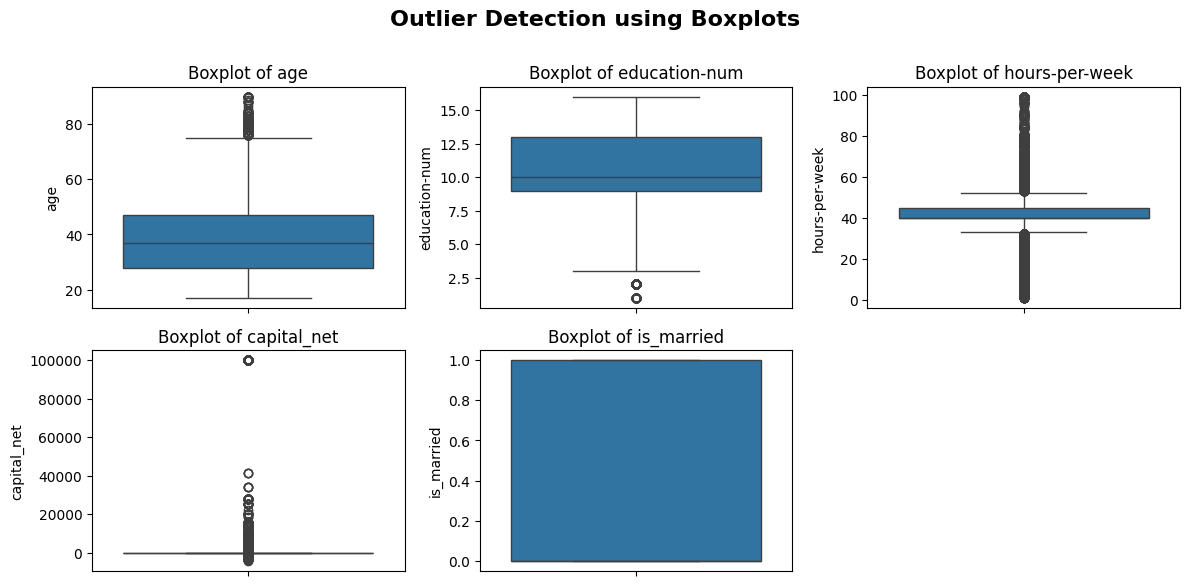

In [12]:
## outliers Detection visually
plt.figure(figsize=(12, 8))

for i, feature in enumerate(num_cols, start=1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.tight_layout()

plt.suptitle("Outlier Detection using Boxplots", fontsize=16,fontweight="bold",y=1.05)

### **3.Handling Skewness**


Text(0.5, 1.05, 'Distribution of Numerical Features')

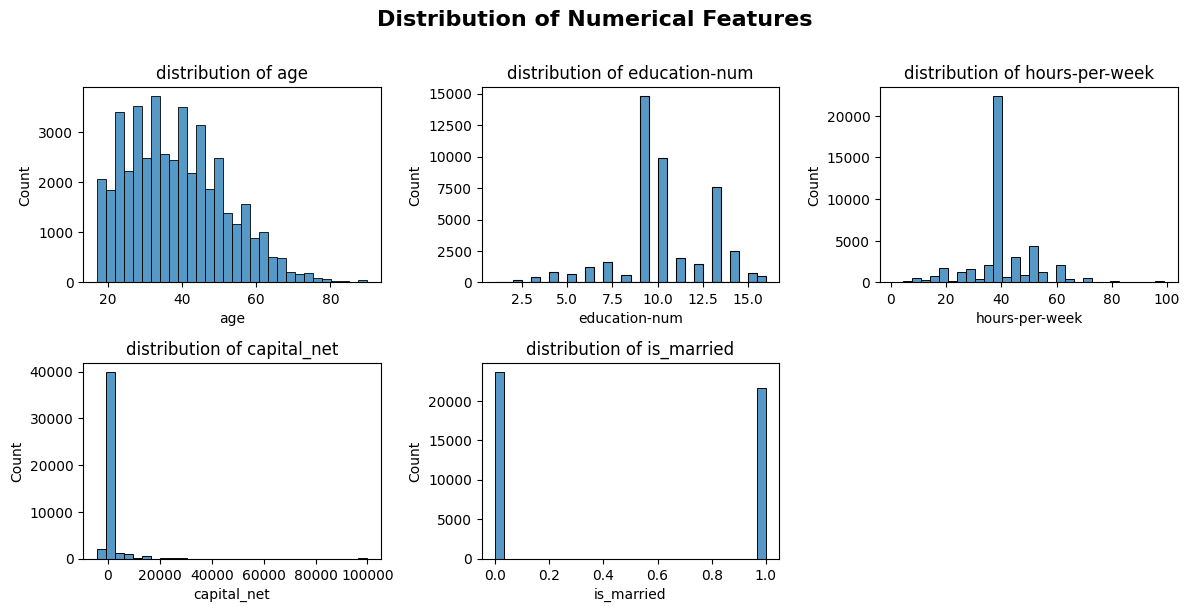

In [13]:
# Skewness Detection visually
plt.figure(figsize=(12, 8))

for i, feature in enumerate(num_cols, start=1):
    plt.subplot(3, 3, i)
    sns.histplot(x=df[feature], bins=30)
    plt.title(f"distribution of {feature}")
    plt.tight_layout()

plt.suptitle("Distribution of Numerical Features", fontsize=16,fontweight="bold",y=1.05)

In [14]:
# Skewness Detiction Analytically
skewness_before = df[num_cols].skew().sort_values(ascending=False) 

print("Skewness before transformation:\n", skewness_before)

Skewness before transformation:
 capital_net       11.709585
age                0.532816
hours-per-week     0.340545
is_married         0.086058
education-num     -0.310621
dtype: float64


In [15]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['capital_net'] = pt.fit_transform(df[['capital_net']])
skewness_after = df[num_cols].skew().sort_values(ascending=False) 


print("Skewness after transformation:\n", skewness_after)

Skewness after transformation:
 capital_net       0.804764
age               0.532816
hours-per-week    0.340545
is_married        0.086058
education-num    -0.310621
dtype: float64


## **Data Visualization**

##### **Target Distribution**

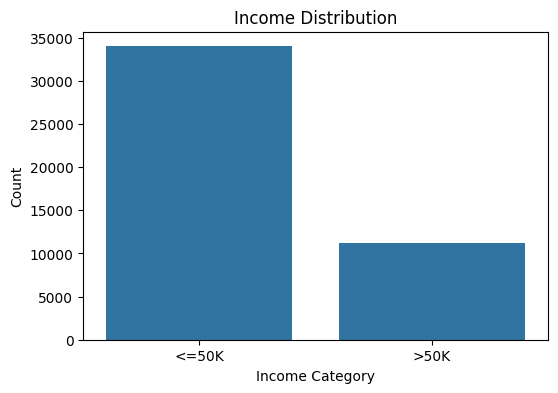

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="income", data=df)

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")

plt.show()

##### **Correlation Heatmap**

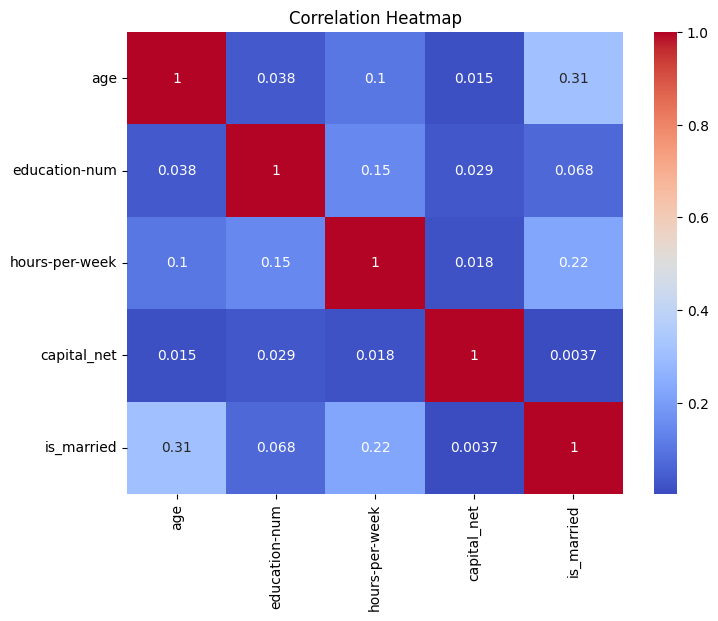

In [17]:
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows weak correlations between most numerical features. This indicates that no strong linear relationship exists among them, which reduces the risk of `multicollinearity` and allows models to learn independent feature contributions.

##### **Income vs Numerical Features**

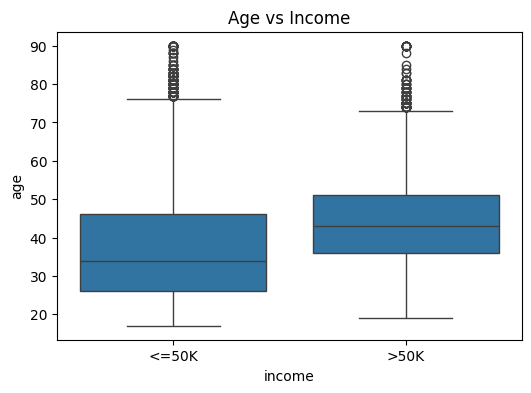

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x="income", y="age", data=df)
plt.title("Age vs Income")

plt.show()

##### **Income vs Categorical Features**

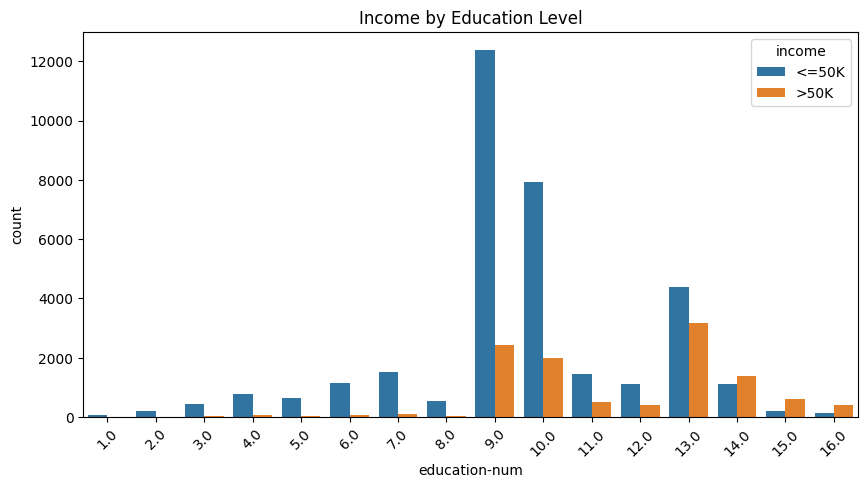

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x="education-num", hue="income", data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")

plt.show()

In [20]:
from sklearn.metrics import f1_score

# y = actual labels
y = df['income']

# Naive predictor predicts everyone as >50K
y_pred = ['>50K'] * len(y)

# Accuracy
accuracy = (y == y_pred).mean()
print("Naive Predictor Accuracy:", accuracy)

# F1 Score
f1 = f1_score(y, y_pred, pos_label='>50K')
print("Naive Predictor F1 Score:", f1)

Naive Predictor Accuracy: 0.2478439697492371
Naive Predictor F1 Score: 0.3972355130249867


## **Data Splitting**

In [21]:
X = df.drop("income", axis=1)
y = df["income"].map({'>50K':1, '<=50K':0})    # mapping the target for better analysis 

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.head()

,age,workclass,education_level,education-num,occupation,relationship,race,sex,hours-per-week,native-country,capital_net,is_married
11772,20,Private,Some-college,10.0,Sales,Not-in-family,White,Female,35.0,United-States,0.046024,0
22476,26,Self-emp-not-inc,Some-college,10.0,Farming-fishing,Husband,White,Male,78.0,United-States,0.046024,1
17763,44,Private,9th,5.0,Machine-op-inspct,Husband,Black,Male,40.0,United-States,0.046024,1
22789,30,Private,HS-grad,9.0,Adm-clerical,Husband,White,Male,40.0,United-States,0.046024,1
26558,31,Private,HS-grad,9.0,Farming-fishing,Not-in-family,White,Male,40.0,Ireland,0.046024,0


In [23]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(exclude='number').columns

## **Pipelines**

##### **Preprocessing for Logistic Regression**

In [24]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor_lr = ColumnTransformer([
    ("num", RobustScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

##### **Logistic Regression Pipeline**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ("preprocessing", preprocessor_lr),
    ("model", LogisticRegression(max_iter=1000 ,random_state=42))
])

##### **Preprocessing for Tree Models (No Scaling)**

In [26]:
preprocessor_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")    # (remainder="passthrough") keeps numeric features unchanged

##### **Decision Tree Pipeline**

In [27]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ("preprocessing", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
])

##### **Random Forest Pipeline**

In [28]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocessing", preprocessor_tree),
    ("model", RandomForestClassifier(random_state=42))
])

#### **AdaBoost Pipeline**

In [29]:
from sklearn.ensemble import  AdaBoostClassifier
pipe_ada = Pipeline([
    ("preprocessing", preprocessor_tree),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1,random_state=42),
        random_state=42
    ))
])

#### **XGBoost Pipeline**

In [30]:
from xgboost import XGBClassifier
pipe_xgb = Pipeline([
    ("preprocessing", preprocessor_tree),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        tree_method="hist"
    ))
])

## **Trainning Models**

In [31]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score

models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "AdaBoost": pipe_ada,
    "XGBoost": pipe_xgb
}

results_cv = {}

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring={"accuracy": make_scorer(accuracy_score), "f1": make_scorer(f1_score)},
        n_jobs=-1
    )
    
    results_cv[name] = {
        "CV Mean Accuracy": cv_results["test_accuracy"].mean(),
        "CV Std Accuracy": cv_results["test_accuracy"].std(),
        "CV Mean F1": cv_results["test_f1"].mean(),
        "CV Std F1": cv_results["test_f1"].std()
    }

results_cv_df = pd.DataFrame(results_cv).T
print("Initial Model Performance (CV on training set):\n", results_cv_df)

Initial Model Performance (CV on training set):
                      CV Mean Accuracy  CV Std Accuracy  CV Mean F1  CV Std F1
Logistic Regression          0.831468         0.002988    0.624019   0.007121
Decision Tree                0.814081         0.004946    0.618855   0.008881
Random Forest                0.840064         0.005314    0.656904   0.010958
AdaBoost                     0.848827         0.004135    0.650641   0.010888
XGBoost                      0.868977         0.002761    0.713371   0.007667


##### **Best Model Extraction**

In [32]:
# choosing the best model based on f1 score
best_model = pipe_xgb

## **HyperParameter Tuning**

In [33]:
from sklearn.model_selection import GridSearchCV

scale = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.7, 0.8]
    # "model__scale_pos_weight": [scale]  # for the class imbalance
}

grid = GridSearchCV(
    estimator=pipe_xgb,        
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1,
    return_train_score=True
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 0.8}


In [34]:
# saving the model to use it in streamlit
import joblib

joblib.dump(best_model, "income_model.pkl")

['income_model.pkl']

In [35]:
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy", "f1"],
    n_jobs=-1
)

print("Tuned XGBoost - CV Mean Accuracy: {:.4f}, CV Mean F1: {:.4f}".format(
    cv_results["test_accuracy"].mean(),
    cv_results["test_f1"].mean()
))


Tuned XGBoost - CV Mean Accuracy: 0.8710, CV Mean F1: 0.7179


In [36]:
y_pred_opt = best_model.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print(f"Tuned XGBoost - Test Accuracy: {acc_opt:.4f}, Test F1: {f1_opt:.4f}")

Tuned XGBoost - Test Accuracy: 0.8678, Test F1: 0.7083


## **Feature Importances**

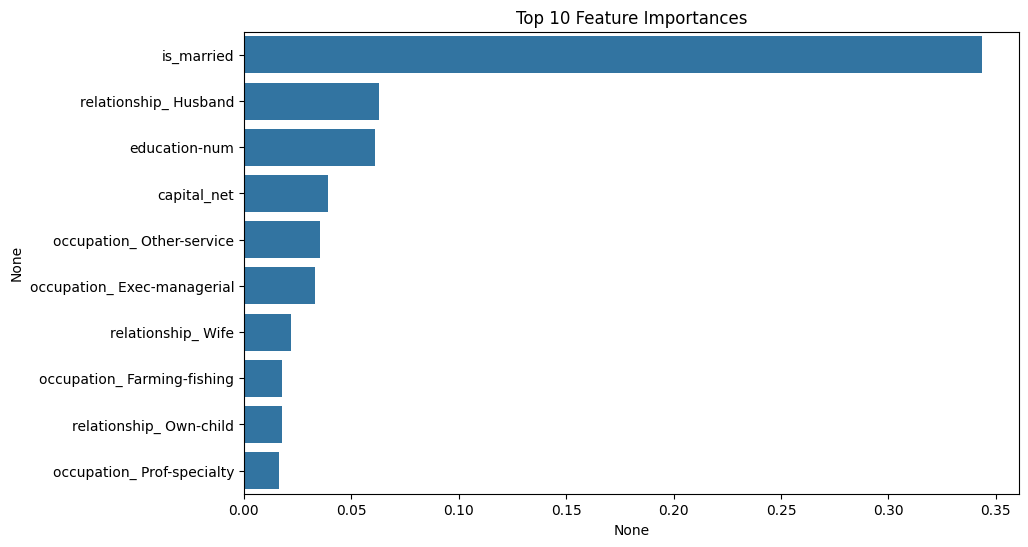

In [37]:
ohe = best_model.named_steps["preprocessing"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = cat_feature_names + list(num_cols)

xgb_model = best_model.named_steps["model"]
importances = pd.Series(xgb_model.feature_importances_, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title("Top 10 Feature Importances")
plt.show()

In [38]:
top5_features = importances.head(5).index

X_train_encoded = best_model.named_steps["preprocessing"].transform(X_train).toarray()
X_test_encoded = best_model.named_steps["preprocessing"].transform(X_test).toarray()

X_train_encoded = pd.DataFrame(X_train_encoded, columns=all_feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=all_feature_names, index=X_test.index)

X_train_top = X_train_encoded[top5_features]
X_test_top = X_test_encoded[top5_features]

pipe_xgb_top5 = Pipeline([
    ("preprocessing", ColumnTransformer([("passthrough", "passthrough", top5_features)])),
    ("model", XGBClassifier(n_estimators=200, random_state=42))
])

pipe_xgb_top5.fit(X_train_top, y_train)
y_pred_top5 = pipe_xgb_top5.predict(X_test_top)

acc_top5 = accuracy_score(y_test, y_pred_top5)
f1_top5 = f1_score(y_test, y_pred_top5)

print(f"Top 5 Features - Accuracy: {acc_top5:.4f}, F1: {f1_top5:.4f}")

Top 5 Features - Accuracy: 0.8568, F1: 0.6634


#### **Another Way to detect the top features**

In [39]:
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipe_xgb_top = Pipeline([
    ("preprocessing", preprocessor_tree),
    
    ("feature_selection",
     SelectFromModel(
         XGBClassifier(n_estimators=200, random_state=42),
         threshold="median"  # take the best 50% features
     )),
    
    ("model", XGBClassifier(n_estimators=200, random_state=42))
])

pipe_xgb_top.fit(X_train, y_train)

y_pred_top = pipe_xgb_top.predict(X_test)

acc_top = accuracy_score(y_test, y_pred_top)
f1_top = f1_score(y_test, y_pred_top)

print(f"Selected Features - Accuracy: {acc_top:.4f}, F1: {f1_top:.4f}")

Selected Features - Accuracy: 0.8663, F1: 0.7069


## **Find the best Threshold**

In [40]:
from sklearn.metrics import precision_recall_curve

probs = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]
print(f"Best threshold by F1: {best_threshold:.2f}")

Best threshold by F1: 0.35
